## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

In [2]:
df = pd.read_csv("C:/DataScienceProjects/Real_Time_Fraud_Detection/dataset/Time_fraud_detection.csv")

df.head()

,TransactionID,UserID,TransactionAmount,TransactionType,MerchantCategory,DeviceType,GeoLocation,Timestamp,IsForeignTransaction,IsHighRiskCountry,PreviousFraudCount,AccountAgeMonths,NumRecentTransactions,AvgTransactionAmount,Label
0,a5415356-579d-49d1-a6a5-988e05cec1b3,dacd53e0-c015-4c5b-8603-4b5f4f42109f,1875.83,Withdrawal,Grocery,Mobile,"-68.6164, 17.4802",2025-07-13 11:19:34,0,0,0,132,25,2197.80,1
1,b4710055-aa61-4462-b762-87391742e457,e66d1f73-0650-4d5e-897c-e06c9dc5896a,4753.82,Purchase,Restaurants,Web,"9.7781, 75.4938",2025-03-30 22:02:59,0,0,0,77,1,2130.45,0
2,adf29176-12fd-41a7-9a48-e16ad713385e,17bd1291-4463-47b4-8418-0f63e3afe5d7,3661.31,Purchase,Electronics,POS Terminal,"-61.7425, 139.1452",2025-05-06 16:19:57,0,1,0,89,25,609.02,0
3,cbcec6d9-a7de-4a14-adf0-43e5725e59a4,c2f9baaf-a2bb-4642-8efa-faee70d3a172,2995.30,Transfer,Restaurants,Mobile,"46.3185, 72.4329",2025-05-01 09:47:32,0,0,0,205,1,640.91,0
4,4cb6509b-0161-4ab6-876d-f4ad2ba9d8fd,2295df6f-7a5b-4b96-b5bc-987a4594256e,784.31,Withdrawal,Restaurants,POS Terminal,"-44.3727, -132.7336",2025-04-11 03:42:15,0,0,1,146,32,2068.00,0


In [3]:
df.shape

(1050, 15)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   TransactionID          1050 non-null   str    
 1   UserID                 1050 non-null   str    
 2   TransactionAmount      1050 non-null   float64
 3   TransactionType        1050 non-null   str    
 4   MerchantCategory       1050 non-null   str    
 5   DeviceType             1050 non-null   str    
 6   GeoLocation            1050 non-null   str    
 7   Timestamp              1050 non-null   str    
 8   IsForeignTransaction   1050 non-null   int64  
 9   IsHighRiskCountry      1050 non-null   int64  
 10  PreviousFraudCount     1050 non-null   int64  
 11  AccountAgeMonths       1050 non-null   int64  
 12  NumRecentTransactions  1050 non-null   int64  
 13  AvgTransactionAmount   1050 non-null   float64
 14  Label                  1050 non-null   int64  
dtypes: float64(2), 

In [5]:
df.columns

Index(['TransactionID', 'UserID', 'TransactionAmount', 'TransactionType',
       'MerchantCategory', 'DeviceType', 'GeoLocation', 'Timestamp',
       'IsForeignTransaction', 'IsHighRiskCountry', 'PreviousFraudCount',
       'AccountAgeMonths', 'NumRecentTransactions', 'AvgTransactionAmount',
       'Label'],
      dtype='str')

## 3. EDA

In [6]:
df.isnull().sum()

TransactionID            0
UserID                   0
TransactionAmount        0
TransactionType          0
MerchantCategory         0
DeviceType               0
GeoLocation              0
Timestamp                0
IsForeignTransaction     0
IsHighRiskCountry        0
PreviousFraudCount       0
AccountAgeMonths         0
NumRecentTransactions    0
AvgTransactionAmount     0
Label                    0
dtype: int64

In [7]:
df.describe()

,TransactionAmount,IsForeignTransaction,IsHighRiskCountry,PreviousFraudCount,AccountAgeMonths,NumRecentTransactions,AvgTransactionAmount,Label
count,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000
mean,2465.141752,0.131429,0.104762,0.300952,115.190476,24.878095,1458.464667,0.027619
std,1466.031809,0.338029,0.306392,0.540891,68.541888,14.068957,840.715329,0.163957
min,28.140000,0.000000,0.000000,0.000000,1.000000,1.000000,10.730000,0.000000
25%,1173.960000,0.000000,0.000000,0.000000,57.250000,13.000000,752.765000,0.000000
50%,2511.765000,0.000000,0.000000,0.000000,110.000000,25.000000,1429.925000,0.000000
75%,3737.395000,0.000000,0.000000,1.000000,175.750000,37.000000,2140.235000,0.000000
max,4998.590000,1.000000,1.000000,3.000000,239.000000,49.000000,2988.080000,1.000000


In [8]:
df['Label'].value_counts()

Label
0    1021
1      29
Name: count, dtype: int64

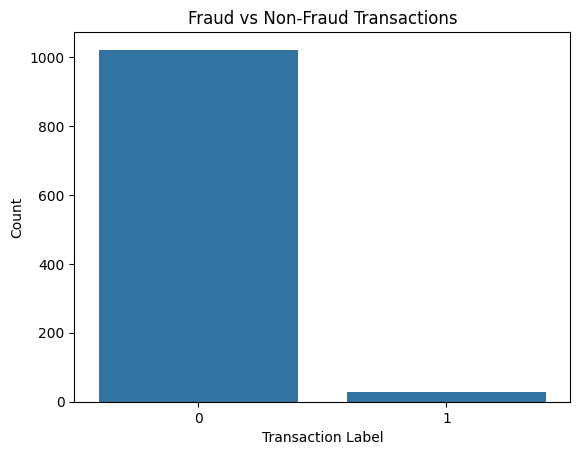

In [9]:
sns.countplot(x='Label', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction Label")
plt.ylabel("Count")
plt.show()

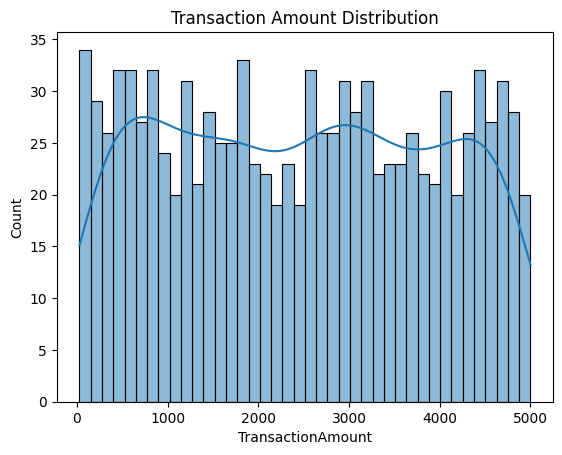

In [10]:
sns.histplot(df['TransactionAmount'], bins=40, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

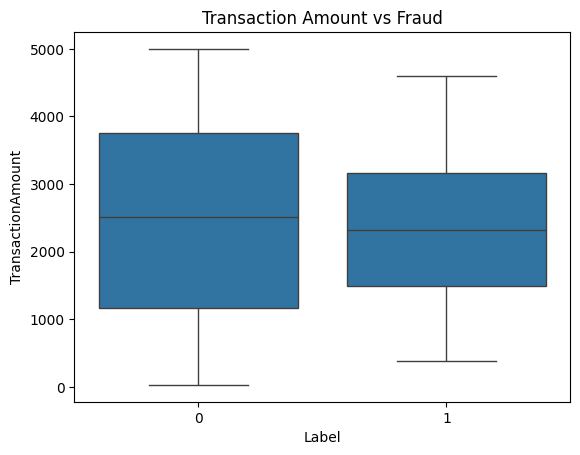

In [11]:
sns.boxplot(x='Label', y='TransactionAmount', data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

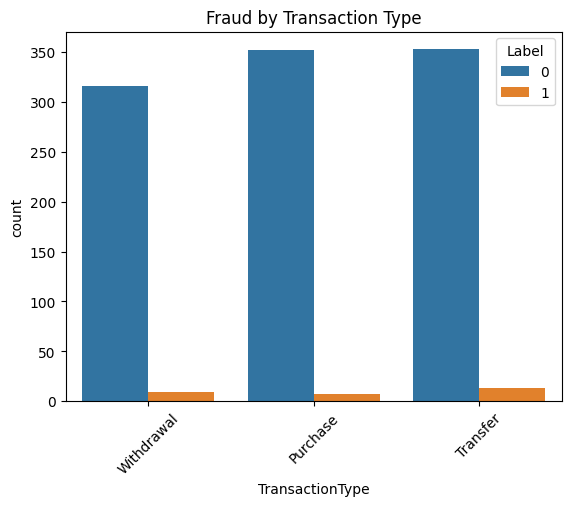

In [12]:
sns.countplot(x='TransactionType', hue='Label', data=df)
plt.title("Fraud by Transaction Type")
plt.xticks(rotation=45)
plt.show()

## 4. Fraud-Risk Feature Engineering

#### 4(a) High Transaction Amount Flag

In [13]:
amount_threshold = df['TransactionAmount'].quantile(0.95)

df['HighTransactionAmountFlag'] = np.where(
    df['TransactionAmount'] > amount_threshold,
    1,
    0
)

#### 4(b) Night Transaction Flag

In [14]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df['TransactionHour'] = df['Timestamp'].dt.hour
df['TransactionDay'] = df['Timestamp'].dt.day
df['TransactionMonth'] = df['Timestamp'].dt.month
df['TransactionDayOfWeek'] = df['Timestamp'].dt.dayofweek

df['NightTransactionFlag'] = np.where(
    (df['TransactionHour'] >= 22) | (df['TransactionHour'] <= 5),
    1,
    0
)

#### 4(c) Location Mismatch Flag

##### (Note: Our dataset does not have separate user and merchant locations, but it has: IsForeignTransaction & IsHighRiskCountry)

##### So we can create a strong location-risk feature:

In [15]:
df['LocationMismatchFlag'] = np.where(
    (df['IsForeignTransaction'] == 1) | (df['IsHighRiskCountry'] == 1),
    1,
    0
)

#### 4(d) Unusual Transaction Frequency

##### Note: Our dataset already has: NumRecentTransactions
##### So we can use that.

In [16]:
frequency_threshold = df['NumRecentTransactions'].quantile(0.95)

df['UnusualTransactionFrequencyFlag'] = np.where(
    df['NumRecentTransactions'] > frequency_threshold,
    1,
    0
)

#### 4(e) Risk Score Column

In [17]:
df['RiskScore'] = (
    df['HighTransactionAmountFlag'] * 25 +
    df['NightTransactionFlag'] * 20 +
    df['LocationMismatchFlag'] * 25 +
    df['UnusualTransactionFrequencyFlag'] * 20 +
    df['PreviousFraudCount'] * 10
)

In [18]:
df[
    [
        'HighTransactionAmountFlag',
        'NightTransactionFlag',
        'LocationMismatchFlag',
        'UnusualTransactionFrequencyFlag',
        'RiskScore',
        'Label'
    ]
].head()

,HighTransactionAmountFlag,NightTransactionFlag,LocationMismatchFlag,UnusualTransactionFrequencyFlag,RiskScore,Label
0,0,0,0,0,0,1
1,1,1,0,0,45,0
2,0,0,1,0,25,0
3,0,0,0,0,0,0
4,0,1,0,0,30,0


## 5. Data Preprocessing

In [19]:
df_model = df.copy()

In [20]:
# Drop unnecessary ID/location/timestamp columns:

df_model.drop(
    columns=['TransactionID', 'UserID', 'GeoLocation', 'Timestamp'],
    inplace=True
)

In [21]:
# Encode categorical columns:

categorical_cols = ['TransactionType', 'MerchantCategory', 'DeviceType']

le = LabelEncoder()

for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])

In [22]:
# Final dataset

df_model.head()

,TransactionAmount,TransactionType,MerchantCategory,DeviceType,IsForeignTransaction,IsHighRiskCountry,PreviousFraudCount,AccountAgeMonths,NumRecentTransactions,AvgTransactionAmount,Label,HighTransactionAmountFlag,TransactionHour,TransactionDay,TransactionMonth,TransactionDayOfWeek,NightTransactionFlag,LocationMismatchFlag,UnusualTransactionFrequencyFlag,RiskScore
0,1875.83,2,2,0,0,0,0,132,25,2197.80,1,0,11,13,7,6,0,0,0,0
1,4753.82,0,3,2,0,0,0,77,1,2130.45,0,1,22,30,3,6,1,0,0,45
2,3661.31,0,1,1,0,1,0,89,25,609.02,0,0,16,6,5,1,0,1,0,25
3,2995.30,1,3,0,0,0,0,205,1,640.91,0,0,9,1,5,3,0,0,0,0
4,784.31,2,3,1,0,0,1,146,32,2068.00,0,0,3,11,4,4,1,0,0,30


## 6. Train-Test Split

In [23]:
X = df_model.drop('Label', axis=1)
y = df_model['Label']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
# Scale for Logistic Regression:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7. Logistic Regression Model

In [26]:
log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [27]:
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [28]:
print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_log))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.98      0.59      0.74       204
           1       0.03      0.50      0.07         6

    accuracy                           0.59       210
   macro avg       0.51      0.55      0.40       210
weighted avg       0.95      0.59      0.72       210

ROC-AUC: 0.5375816993464052


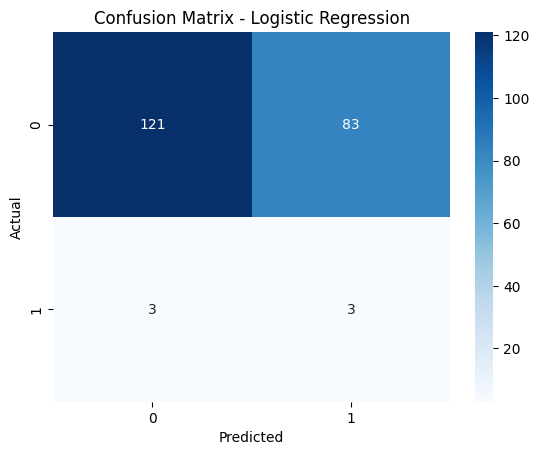

In [29]:
# Confusion Matrix

cm_log = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("results/confusion_matrix_logistic.png", bbox_inches='tight')
plt.show()

## 8. Random Forest Model

In [30]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [31]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [32]:
print("Random Forest Classification Report")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       204
           1       0.00      0.00      0.00         6

    accuracy                           0.97       210
   macro avg       0.49      0.50      0.49       210
weighted avg       0.94      0.97      0.96       210

ROC-AUC: 0.47998366013071897


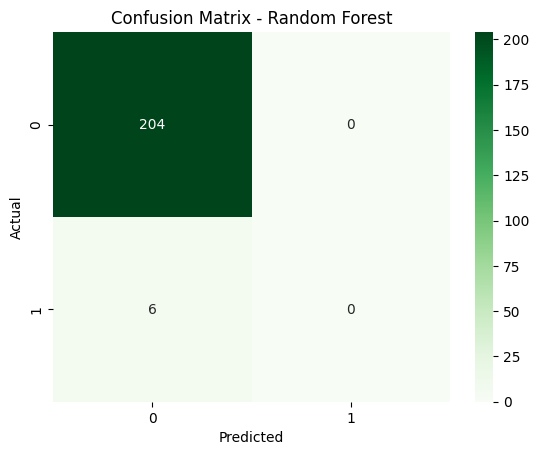

In [33]:
# Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("results/confusion_matrix_random_forest.png", bbox_inches='tight')
plt.show()

## 9. Model Comparison

In [34]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.034884,0.5,0.065217,0.537582
1,Random Forest,0.000000,0.0,0.000000,0.479984


## 10. ROC Curve

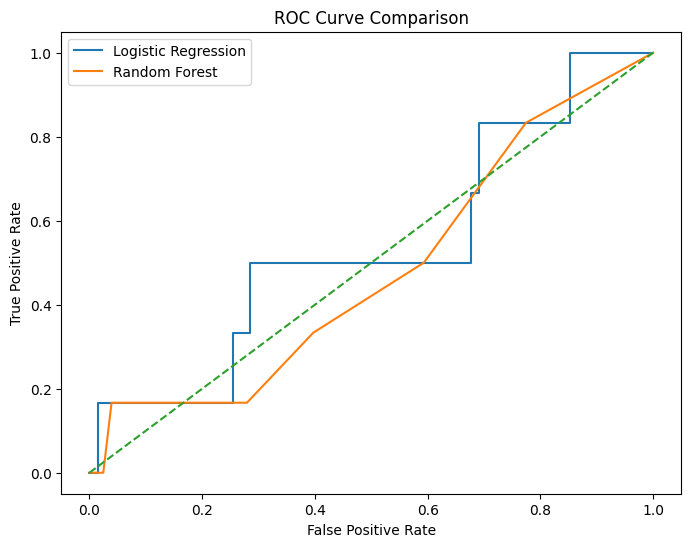

In [35]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig("results/roc_curve.png", bbox_inches='tight')
plt.show()

## Feature Importance

In [36]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
0,TransactionAmount,0.134181
9,AvgTransactionAmount,0.130358
7,AccountAgeMonths,0.119440
12,TransactionDay,0.096644
11,TransactionHour,0.093141
8,NumRecentTransactions,0.085809
14,TransactionDayOfWeek,0.063106
13,TransactionMonth,0.050316
18,RiskScore,0.045067
2,MerchantCategory,0.042665


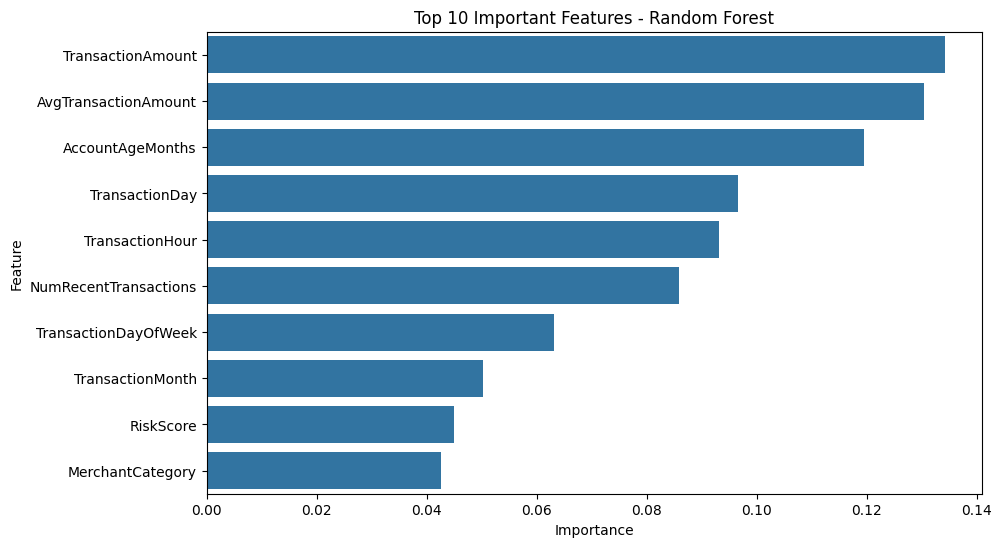

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features - Random Forest")
plt.savefig("results/feature_importance.png", bbox_inches='tight')
plt.show()

## 12. Best Model

In [38]:
best_model = results.sort_values(by='Recall', ascending=False).iloc[0]

print("Best Model Based on Recall:")
print(best_model)

Best Model Based on Recall:
Model        Logistic Regression
Precision               0.034884
Recall                       0.5
F1-Score                0.065217
ROC-AUC                 0.537582
Name: 0, dtype: object
